# Advanto Social Network Analysis
**Course:** Social Networks in Organizations — Group Project (Heidi Roizen lecture, [L11])
**Client:** *Advanto* CEO  •  **Brief:** evaluate post-merger integration and recommend a 3-person task force

We work with three datasets:
1. **Demographics** — individual attributes of the 26 managers (input for homophily tests, [L7])
2. **Event attendance** — bipartite manager × event participation matrix ([L9])
3. **Communication network** — directed work-communication ties (the focal network, [L3])

**Analytical roadmap.** Section 2–3 profile the actors and the formal integration mechanism (events). Section 4 analyses the communication network using centrality ([L3]), E-I index ([L14]), community detection ([L5]), and structural holes ([L6]). Section 5 tests *which* attributes drive tie formation using MR-QAP ([L18]). Section 6 identifies sabotage risk and applies Krackhardt's Power×Resistance grid ([L14]). Section 7 designs the task force and simulates its projected impact. Section 8 summarises diagnostics in a one-page health scorecard.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
import seaborn as sns 
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
demo   = pd.read_csv('manager_demographics.csv')
events = pd.read_csv('event_attendance.csv').set_index('Manager')
edges  = pd.read_csv('communication_network.csv')

# pandas reads 'None' strings as NaN — restore as a label
demo['Legacy_Organization'] = demo['Legacy_Organization'].fillna('Post-merger')
demo['Favor_Merger']        = demo['Favor_Merger'].fillna('N/A')

print('Demographics:', demo.shape)
print('Events:', events.shape)
print('Edges:', edges.shape)
demo.head()

Demographics: (26, 8)
Events: (26, 8)
Edges: (102, 2)


,Manager,Gender,Age,Education,Legacy_Organization,Self_Monitoring,Brokerage_Orientation,Favor_Merger
0,1,F,30,MBA,Post-merger,5,TI,N/A
1,2,F,25,MSc,Brightway,2,TG,Y
2,3,M,40,MSc,Genesisphere,1,TG,Y
3,4,F,42,MBA,Post-merger,3,TI,N/A
4,5,F,54,MSc,Brightway,4,TG,Y


## 2. Demographics Analysis

Before analysing the network, we profile the 26 managers along key demographic and psychological dimensions. These attributes will serve as **predictors in the MR-QAP regression** (Section 5, [L18]) to test which characteristics drive communication tie formation — and which ones do not.

Two attributes deserve highlighting: **Brokerage Orientation** distinguishes *Tertius Iungens* (TI, collaborative connectors) from *Tertius Gaudens* (TG, arbitragers who exploit structural gaps), the dispositional axis introduced in [L6] and developed in Soda, Tortoriello & Iorio (2018). **Self-Monitoring** captures behavioural adaptability across social contexts ([L11], Heidi Roizen case).

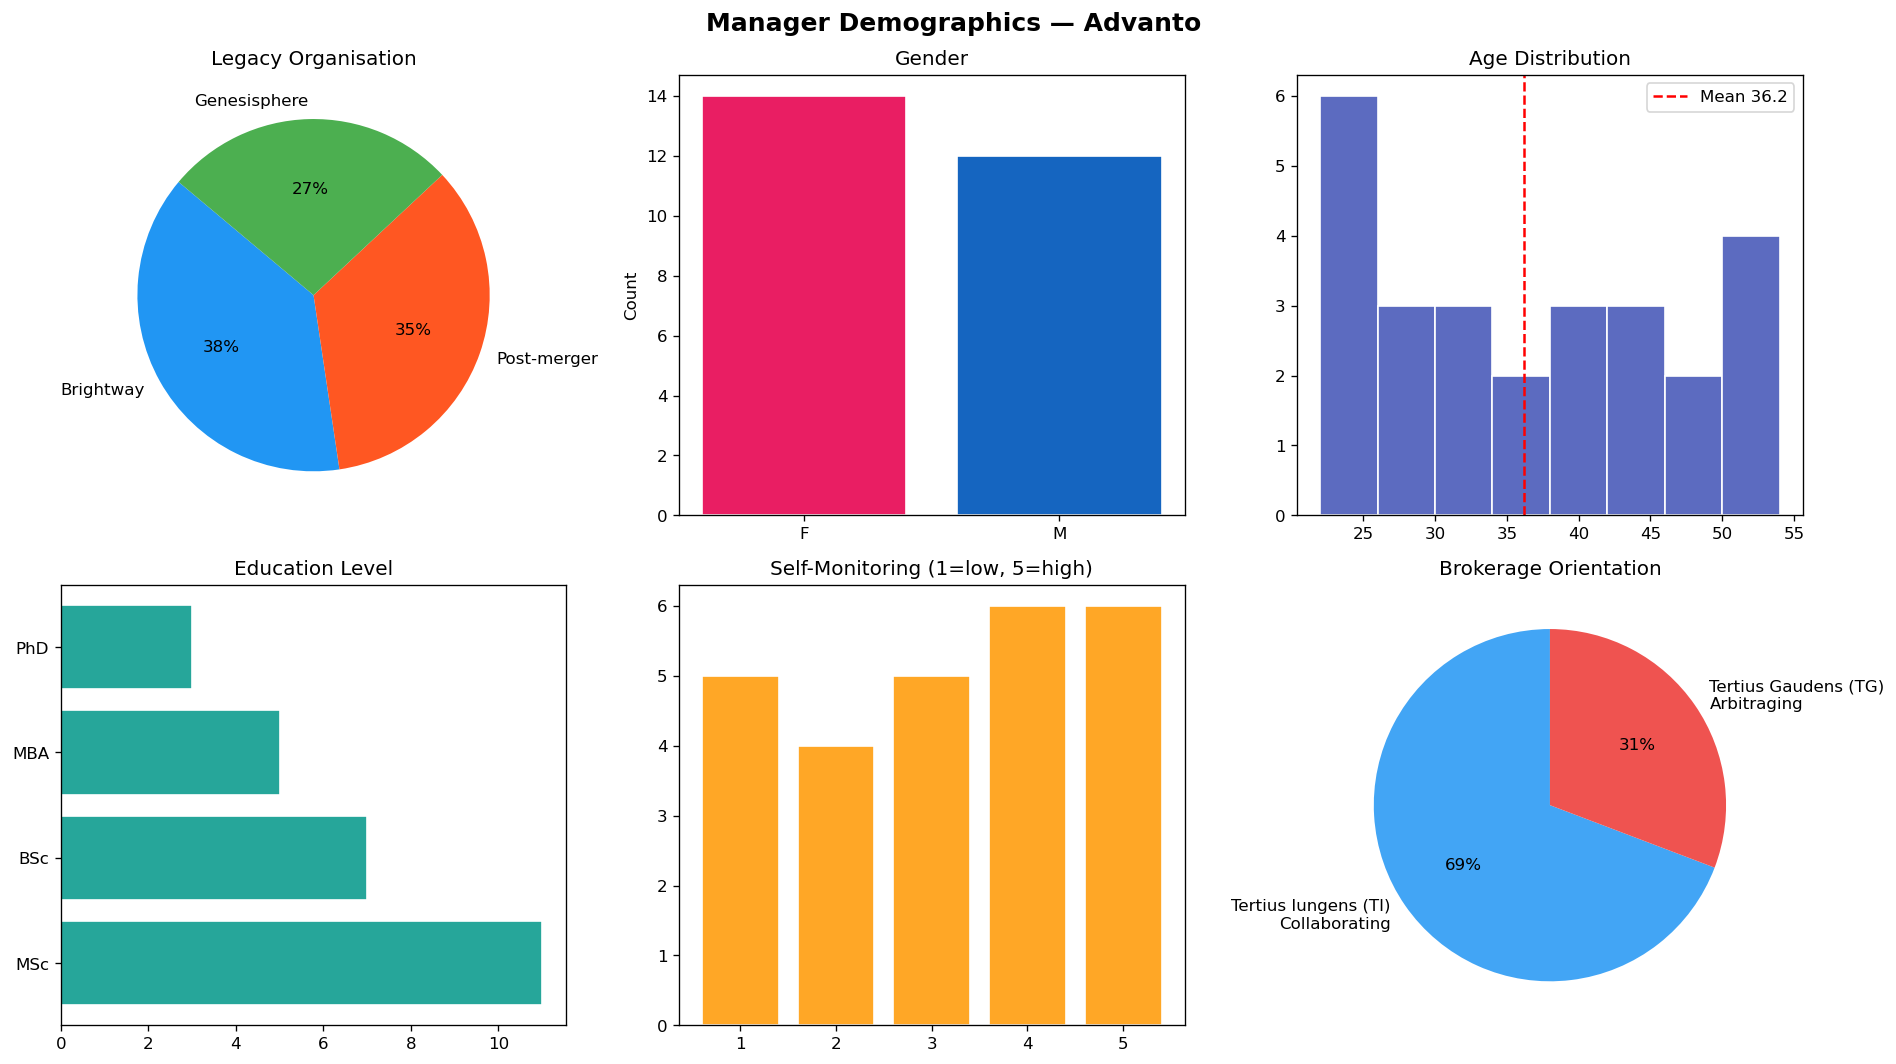

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Manager Demographics — Advanto', fontsize=15, fontweight='bold')

# Legacy organisation
lc = demo['Legacy_Organization'].value_counts()
axes[0,0].pie(lc, labels=lc.index, autopct='%1.0f%%',
              colors=['#2196F3','#FF5722','#4CAF50','#9E9E9E'], startangle=140)
axes[0,0].set_title('Legacy Organisation')

# Gender
gc = demo['Gender'].value_counts()
axes[0,1].bar(gc.index, gc.values, color=['#E91E63','#1565C0'], edgecolor='white')
axes[0,1].set_title('Gender')
axes[0,1].set_ylabel('Count')

# Age
axes[0,2].hist(demo['Age'], bins=8, color='#5C6BC0', edgecolor='white')
axes[0,2].axvline(demo['Age'].mean(), color='red', linestyle='--',
                  label=f'Mean {demo["Age"].mean():.1f}')
axes[0,2].set_title('Age Distribution')
axes[0,2].legend()

# Education
ec = demo['Education'].value_counts()
axes[1,0].barh(ec.index, ec.values, color='#26A69A', edgecolor='white')
axes[1,0].set_title('Education Level')

# Self-monitoring
sm = demo['Self_Monitoring'].value_counts().sort_index()
axes[1,1].bar(sm.index.astype(str), sm.values, color='#FFA726', edgecolor='white')
axes[1,1].set_title('Self-Monitoring (1=low, 5=high)')

# Brokerage orientation
bo = demo['Brokerage_Orientation'].value_counts()
axes[1,2].pie(bo, labels=['Tertius Iungens (TI)\nCollaborating',
                           'Tertius Gaudens (TG)\nArbitraging'],
              autopct='%1.0f%%', colors=['#42A5F5','#EF5350'], startangle=90)
axes[1,2].set_title('Brokerage Orientation')

plt.tight_layout()
plt.savefig('png/2.1.png', bbox_inches='tight')
plt.show()

**Key demographic patterns:**
- **Three legacy groups:** Brightway (10, 38%), Genesisphere (7, 27%), post-merger hires (9, 35%) — the structural identity dimension that drives most of the analysis ([L7], status homophily)
- **Gender:** Near-equal split (~50/50 F/M) — relevant for the Heidi Roizen case discussion of gendered networking perceptions ([L11])
- **Age:** Wide range 22–54 (mean ≈ 35) — potential generational propinquity effect on communication ([L7])
- **Self-monitoring:** Bimodal distribution — many managers at extremes (1 or 5), few in the middle ([L11])
- **Brokerage:** 69% TI (collaborative/connecting) vs 31% TG (arbitraging/exploiting gaps) ([L6])

Merger support by legacy org:
Favor_Merger         N  Y
Legacy_Organization      
Brightway            3  7
Genesisphere         5  2

Percentages:
Favor_Merger            N     Y
Legacy_Organization            
Brightway            30.0  70.0
Genesisphere         71.4  28.6


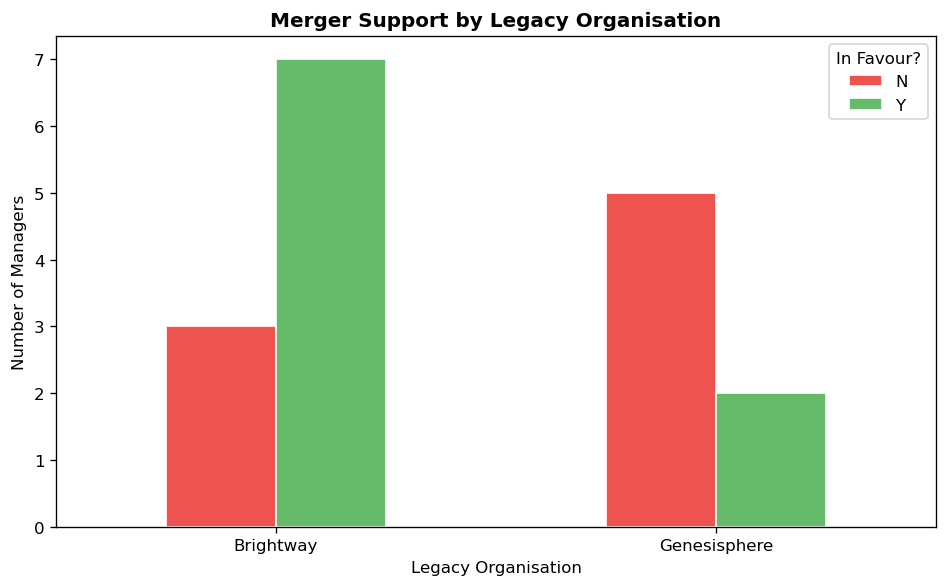

In [4]:
# Merger support by legacy org
favor = demo[(demo['Legacy_Organization'] != 'None') & (demo['Favor_Merger'] != 'N/A')].copy()
cross = pd.crosstab(favor['Legacy_Organization'], favor['Favor_Merger'])
print('Merger support by legacy org:')
print(cross)
print()
print('Percentages:')
print((cross.div(cross.sum(axis=1), axis=0) * 100).round(1))

fig, ax = plt.subplots(figsize=(8, 5))
cross.plot(kind='bar', ax=ax, color=['#EF5350','#66BB6A'], edgecolor='white', rot=0)
ax.set_title('Merger Support by Legacy Organisation', fontweight='bold')
ax.set_xlabel('Legacy Organisation')
ax.set_ylabel('Number of Managers')
ax.legend(title='In Favour?')
plt.tight_layout()
plt.savefig('png/2.2.png', bbox_inches='tight')
plt.show()

**Critical finding — ideological split along legacy lines:**
- **Brightway:** 67% pro-merger (Y), 33% anti-merger (N)
- **Genesisphere:** 33% pro-merger, 67% anti-merger

The merger was designed as a 50:50 union, but attitudes are deeply asymmetric. Genesisphere managers predominantly oppose the integration — likely perceiving cultural or strategic loss. This divide maps directly onto the organisational boundaries the merger was supposed to dissolve, producing **value homophily** along legacy lines ([L7]) and is the primary motivation for the CEO's sabotage concern.

## 3. Event Attendance — Bipartite Network

Beyond daily communication, *Advanto* organises company-wide events as a formal integration mechanism. Following [L9], we model attendance as a **two-mode (bipartite) network** (managers ↔ events) and compute its **one-mode projection** onto a manager co-attendance graph. Two managers are connected in the projection if they attended at least one event together; edge weight = number of shared events.

This reveals two things:
1. Whether events are actually mixing legacy groups (cross-legacy co-attendance rate)
2. Whether event co-attendance predicts work communication ties (tested in MR-QAP, Section 5, [L18])

**Methodological caveat ([L9]):** projections of bipartite graphs tend to inflate clustering coefficients artificially; we therefore interpret projection-based clustering metrics with care and rely on co-attendance ties as a *predictor*, not as a structural conclusion in itself.

In [5]:
events_total = events.sum(axis=1).rename('events_attended')
demo = demo.merge(events_total.reset_index(), on='Manager')

print('Events attended per manager:')
print(events_total.describe().round(2))
print(f'\nManagers attending 0 events: {(events_total == 0).sum()}')
print('\nAttendance per event:')
print(events.sum(axis=0))

Events attended per manager:
count    26.00
mean      1.31
std       0.97
min       0.00
25%       1.00
50%       1.00
75%       2.00
max       3.00
Name: events_attended, dtype: float64

Managers attending 0 events: 6

Attendance per event:
E1    5
E2    5
E3    4
E4    3
E5    3
E6    5
E7    6
E8    3
dtype: int64


**Attendance is sparse:** average 1.3 events per manager; **6 managers (23%) attended zero events** — they are completely absent from formal integration mechanisms. Low baseline participation limits events' integration potential before we even examine who attends with whom — a structural problem the recommendations in Section 7 address by redesigning event invitations along Kotter's "remove barriers" step ([L14]).

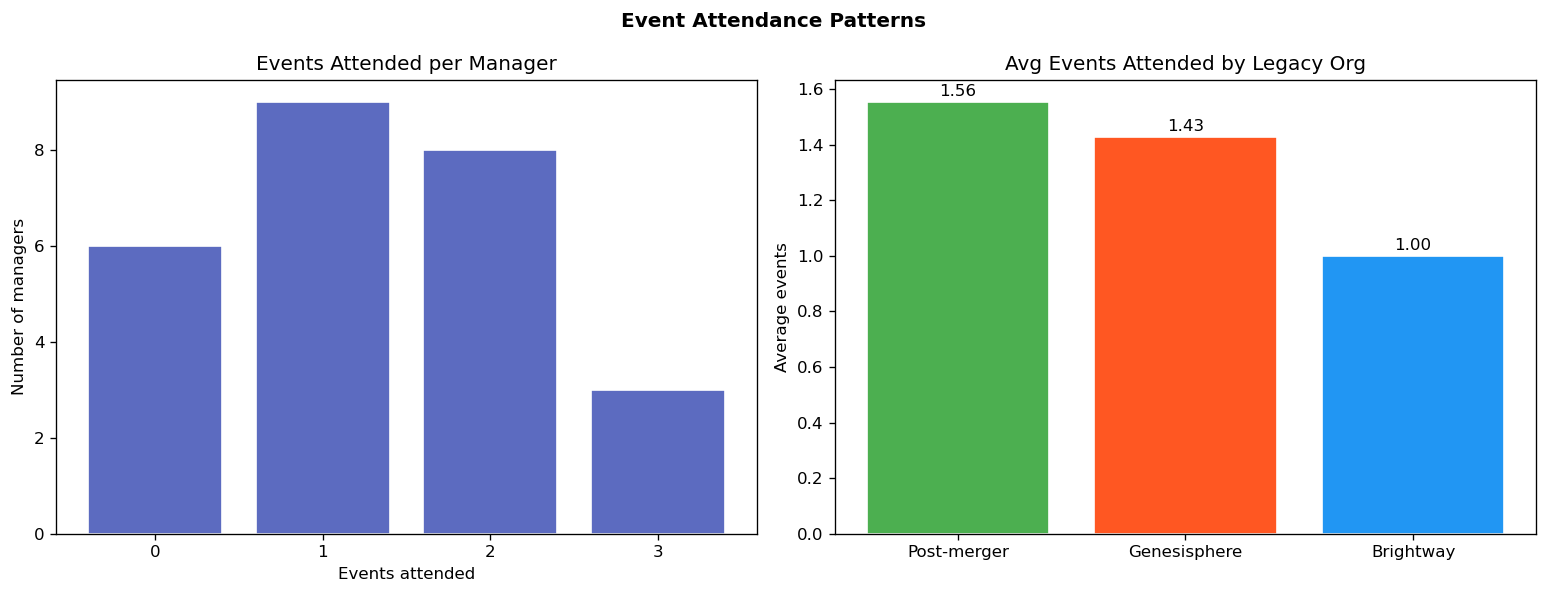

In [6]:
legacy_lookup = dict(zip(demo['Manager'], demo['Legacy_Organization']))
color_map_leg = {'Brightway':'#2196F3','Genesisphere':'#FF5722','Post-merger':'#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Event Attendance Patterns', fontweight='bold')

vc = events_total.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='#5C6BC0', edgecolor='white')
axes[0].set_title('Events Attended per Manager')
axes[0].set_xlabel('Events attended')
axes[0].set_ylabel('Number of managers')
axes[0].set_xticks(vc.index)

la = demo.groupby('Legacy_Organization')['events_attended'].mean().sort_values(ascending=False)
bars = axes[1].bar(la.index, la.values,
                   color=[color_map_leg.get(x,'grey') for x in la.index], edgecolor='white')
axes[1].set_title('Avg Events Attended by Legacy Org')
axes[1].set_ylabel('Average events')
for bar, val in zip(bars, la.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.savefig('png/3.1.png', bbox_inches='tight')
plt.show()

In [7]:
# Build bipartite graph
from networkx.algorithms import bipartite

B = nx.Graph()
managers_list = [f'M{i}' for i in range(1, 27)]
event_nodes   = events.columns.tolist()
B.add_nodes_from(managers_list, bipartite=0)
B.add_nodes_from(event_nodes, bipartite=1)

for mgr_id, row in events.iterrows():
    for evt, val in row.items():
        if val == 1:
            B.add_edge(f'M{mgr_id}', evt)

# Co-attendance projection
co_attend = bipartite.weighted_projected_graph(B, set(managers_list))

cross_leg = sum(1 for u, v in co_attend.edges()
                if legacy_lookup.get(int(u[1:]),'?') != legacy_lookup.get(int(v[1:]),'?')
                and legacy_lookup.get(int(u[1:]),'?') != 'None'
                and legacy_lookup.get(int(v[1:]),'?') != 'None')
print(f'Co-attendance network: {co_attend.number_of_nodes()} nodes, {co_attend.number_of_edges()} edges')
print(f'Cross-legacy co-attendance ties: {cross_leg}')

Co-attendance network: 26 nodes, 55 edges
Cross-legacy co-attendance ties: 33


In [8]:
def node_color(mid):
    return color_map_leg.get(legacy_lookup.get(mid, 'None'), 'grey')

In [ ]:

# --- Bipartite network: Kamada-Kawai layout ---
manager_nodes = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 0]
event_nodes_b = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 1]

# Main connected component only
main_comp_B = max(nx.connected_components(B), key=len)
B_main = B.subgraph(main_comp_B)
n_isolated_B = B.number_of_nodes() - len(main_comp_B)
pos_B = nx.kamada_kawai_layout(B_main)
mgr_main  = [n for n in manager_nodes if n in main_comp_B]
evt_main  = [n for n in event_nodes_b if n in main_comp_B]

# Co-attendance: main component only
main_comp_co = max(nx.connected_components(co_attend), key=len)
co_main = co_attend.subgraph(main_comp_co)
n_isolated_co = co_attend.number_of_nodes() - len(main_comp_co)
pos_co = nx.kamada_kawai_layout(co_main)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Event Attendance Networks', fontsize=13, fontweight='bold')

# Bipartite graph
nx.draw_networkx_edges(B_main, pos_B, alpha=0.6, edge_color='#444', ax=axes[0])
nx.draw_networkx_nodes(B_main, pos_B, nodelist=mgr_main, node_color='#5C6BC0',
                       node_size=380, node_shape='o', alpha=0.9, ax=axes[0])
nx.draw_networkx_nodes(B_main, pos_B, nodelist=evt_main, node_color='#FFA726',
                       node_size=680, node_shape='s', alpha=0.9, ax=axes[0])
nx.draw_networkx_labels(B_main, pos_B, font_size=9, font_weight='bold', ax=axes[0])
axes[0].legend(handles=[
    mpatches.Patch(color='#5C6BC0', label='Manager'),
    mpatches.Patch(color='#FFA726', label='Event'),
], loc='upper left', fontsize=9)
t0 = 'Two-Mode Network: Managers × Events (Kamada-Kawai)'
if n_isolated_B > 0:
    t0 += f'\n({n_isolated_B} isolated node{"s" if n_isolated_B > 1 else ""} not shown)'
axes[0].set_title(t0, fontweight='bold')
axes[0].axis('off')

# Co-attendance projection
edge_weights = [co_main[u][v]['weight'] for u, v in co_main.edges()]
node_colors_co = [node_color(int(n[1:])) for n in co_main.nodes()]
nx.draw_networkx_edges(co_main, pos_co, width=[w * 1.5 for w in edge_weights],
                       alpha=0.7, edge_color='#444', ax=axes[1])
nx.draw_networkx_nodes(co_main, pos_co, node_color=node_colors_co, node_size=510,
                       alpha=0.9, ax=axes[1])
nx.draw_networkx_labels(co_main, pos_co, font_size=10, font_weight='bold', ax=axes[1])
axes[1].legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
    Line2D([0],[0], color='grey', linewidth=2, label='Edge weight = shared events'),
], loc='upper left', fontsize=9)
t1 = 'One-Mode Projection: Manager-by-Manager (edge weight = shared events)'
if n_isolated_co > 0:
    t1 += f'\n({n_isolated_co} isolated node{"s" if n_isolated_co > 1 else ""} not shown)'
axes[1].set_title(t1, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('png/3.2.png', bbox_inches='tight')
plt.show()


### Key Insight: Co-attendance as Integration Lever

Cross-legacy co-attendance accounts for **33 of 55 ties (60%)** in the projected event network — higher cross-legacy mixing than the communication network (47%). Events already bridge legacy groups more than spontaneous communication does, partially counteracting legacy homophily ([L7]).

**Confirmed in MR-QAP (Section 5, [L18]):** co-attendance is the strongest and most significant predictor of communication ties (β ≈ +0.12, p < .01) — stronger than any demographic attribute. Deliberately designing future events to mix Brightway and Genesisphere managers is the single most actionable integration lever, consistent with the [L14] principle that *informal* mixing channels drive change adoption more reliably than top-down mandates.

*Course concepts used:* two-mode networks & projection [L9]; homophily [L7]; MR-QAP [L18]; managing change via informal structure [L14].

## 4. Communication Network — Core Analysis

The communication network is the central object of our analysis. We construct a **directed graph** ([L3]) from self-reported work communication ties among all 26 managers and compute five centrality measures to profile each manager's structural position.

**Caveat on self-report ([L10], Cognitive Social Structures):** managers' perceptions of who they communicate with may diverge from actual communication patterns — Krackhardt (1987) shows individuals systematically misperceive even their own networks. Ideally we would triangulate with email/Slack metadata ([L15], data collection). For this engagement we accept the self-report data, noting that high agreement among reciprocated nominations (visible in the symmetry of the adjacency matrix) provides some internal validation.

The structural positions we compute determine two things:
1. **Integration potential** — who can bridge legacy groups (→ Task Force, Section 7)
2. **Sabotage risk** — who can block integration from a position of structural power (→ Section 6)

In [10]:
# Build directed and undirected communication graphs
G_dir = nx.DiGraph()
G_dir.add_nodes_from(demo['Manager'])
for _, row in edges.iterrows():
    G_dir.add_edge(int(row['Source']), int(row['Target']))

G = G_dir.to_undirected()

print(f'Directed:   {G_dir.number_of_nodes()} nodes, {G_dir.number_of_edges()} edges')
print(f'Undirected: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Directed:   26 nodes, 102 edges
Undirected: 26 nodes, 51 edges


In [11]:
# Centrality measures
deg_in    = dict(G_dir.in_degree())
deg_out   = dict(G_dir.out_degree())
deg_total = dict(G.degree())
between   = nx.betweenness_centrality(G, normalized=True)
closeness = nx.closeness_centrality(G)
eigenvec  = nx.eigenvector_centrality(G, max_iter=500)
constraint_vals = nx.constraint(G)

centrality_df = pd.DataFrame({
    'Manager':    list(G.nodes()),
    'Degree':     [deg_total[n] for n in G.nodes()],
    'In_Degree':  [deg_in.get(n, 0) for n in G.nodes()],
    'Out_Degree': [deg_out.get(n, 0) for n in G.nodes()],
    'Betweenness':[between[n]   for n in G.nodes()],
    'Closeness':  [closeness[n] for n in G.nodes()],
    'Eigenvector':[eigenvec[n]  for n in G.nodes()],
    'Constraint': [constraint_vals[n] for n in G.nodes()],
})
centrality_df = (centrality_df
                 .sort_values('Manager')
                 .merge(demo[['Manager','Legacy_Organization','Brokerage_Orientation',
                               'Self_Monitoring','Favor_Merger','events_attended']], on='Manager')
                 .reset_index(drop=True))

print('Top 10 by Betweenness:')
print(centrality_df.sort_values('Betweenness', ascending=False)[
    ['Manager','Legacy_Organization','Degree','Betweenness','Closeness','Constraint']
].head(10).round(4).to_string(index=False))

Top 10 by Betweenness:
 Manager Legacy_Organization  Degree  Betweenness  Closeness  Constraint
      11           Brightway       4       0.5000     0.3846      0.3753
       1         Post-merger       5       0.3556     0.3571      0.2888
       8           Brightway       5       0.3514     0.3906      0.3339
      22         Post-merger       3       0.2811     0.2907      0.3333
      13        Genesisphere       4       0.2339     0.3425      0.4319
      12        Genesisphere       4       0.1972     0.3378      0.4319
       6           Brightway       5       0.1664     0.3623      0.3609
      17        Genesisphere       7       0.1586     0.2941      0.3017
      14        Genesisphere       5       0.1214     0.2874      0.2848
      26         Post-merger       3       0.0733     0.2358      0.5062


**Centrality measures ([L3], [L6]):**
- **Degree** ([L3]): number of direct contacts — basic activity/popularity
- **Betweenness** ([L3]): fraction of shortest paths passing through a node — measures information control and bridge potential; the canonical brokerage measure ([L6])
- **Closeness** ([L3]): inverse average distance to all others — measures how quickly a manager can reach the whole network
- **Eigenvector** ([L3]): connection to well-connected others — quality of connections, not just quantity
- **Burt's Constraint** ([L6]): how redundant a manager's contacts are — *low constraint* = structural hole broker spanning disconnected groups; *high constraint* = embedded in a single dense cluster. Constraint depends on three components — size, density, and hierarchy of the ego network — and is correlated with superior performance in the brokerage literature (Burt, 2004).

In [12]:
top10 = (centrality_df
    .sort_values('Betweenness', ascending=False)
    .head(10)[['Manager','Legacy_Organization','Favor_Merger',
               'Brokerage_Orientation','Degree','Betweenness','Constraint']]
    .rename(columns={
        'Legacy_Organization':   'Legacy Org',
        'Favor_Merger':          'Pro Merger?',
        'Brokerage_Orientation': 'Brokerage',
    })
    .assign(Manager=lambda df: df['Manager'].apply(lambda x: f'M{int(x)}'))
    .reset_index(drop=True)
)

top10.style \
    .set_caption('Top 10 Managers by Betweenness Centrality') \
    .format({'Betweenness': '{:.3f}', 'Constraint': '{:.3f}'}) \
    .background_gradient(subset=['Betweenness'], cmap='YlOrRd') \
    .background_gradient(subset=['Constraint'], cmap='YlGn_r') \
    .set_properties(**{'text-align': 'center'}) \
    .hide(axis='index')


Manager,Legacy Org,Pro Merger?,Brokerage,Degree,Betweenness,Constraint
M11,Brightway,N,TG,4,0.500,0.375
M1,Post-merger,N/A,TI,5,0.356,0.289
M8,Brightway,N,TG,5,0.351,0.334
M22,Post-merger,N/A,TG,3,0.281,0.333
M13,Genesisphere,N,TI,4,0.234,0.432
M12,Genesisphere,N,TI,4,0.197,0.432
M6,Brightway,Y,TI,5,0.166,0.361
M17,Genesisphere,Y,TI,7,0.159,0.302
M14,Genesisphere,N,TI,5,0.121,0.285
M26,Post-merger,N/A,TI,3,0.073,0.506


**Key structural players ([L6], structural holes):**
- **M11** (Brightway): Highest betweenness (0.50) — more than any other manager. Sits at the critical bridge between Brightway and Genesisphere clusters.
- **M1** (Post-merger): Second highest betweenness (0.36), lowest constraint (0.29) — strongest structural-hole broker in the network.
- **M8, M22** (Brightway, Post-merger): High betweenness with significant broker potential.

Three managers — **M1, M11, M22** — are **articulation points** ([L3]): removing any one of them disconnects the communication network entirely. This is the structural fragility the CEO's concern is rooted in: the integration depends on three individuals.

### 4.1 Network Visualisation

In [ ]:
def node_color(mid):
    return color_map_leg.get(legacy_lookup.get(mid, 'None'), 'grey')

# Draw only the main connected component
main_comp = max(nx.connected_components(G), key=len)
G_main = G.subgraph(main_comp)
n_isolated = G.number_of_nodes() - len(main_comp)

pos = nx.kamada_kawai_layout(G_main)
node_color_list = [node_color(n) for n in G_main.nodes()]
node_size_list  = [400 + between[n] * 8000 for n in G_main.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(G_main, pos, alpha=0.5, edge_color='#555', ax=ax, width=0.8)
nx.draw_networkx_nodes(G_main, pos, node_color=node_color_list,
                       node_size=node_size_list, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_main, pos, font_size=9, font_weight='bold', ax=ax)
legend_els = [
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
           markersize=12, label='Node size ∝ Betweenness'),
]
ax.legend(handles=legend_els, loc='upper left', fontsize=9)
title = 'Advanto Communication Network (node size = betweenness)'
if n_isolated > 0:
    title += f'\n({n_isolated} isolated node{"s" if n_isolated > 1 else ""} not shown)'
ax.set_title(title, fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('png/4.1.png', bbox_inches='tight')
plt.show()

**Visual pattern:** Three clusters are visible — a Brightway-dominated cluster (bottom), a Genesisphere-dominated cluster (top-right), and a post-merger isolate cluster (right). Cross-legacy ties exist but pass through a small number of bridge managers — a clear **small-world-like, modular topology** ([L5]) where most ties are within-cluster and a few brokers carry the cross-cluster traffic. Node size reflects betweenness — the largest nodes (M11, M1, M8) are the structural linchpins of the entire network ([L6]).

### 4.2 Legacy Clustering — E-I Index

In [14]:
# Count within vs cross-legacy ties
within_bw, within_gs, cross_ties, other = 0, 0, 0, 0
for u, v in G.edges():
    ou, ov = legacy_lookup.get(u,'None'), legacy_lookup.get(v,'None')
    if   ou == 'Brightway'    and ov == 'Brightway':    within_bw += 1
    elif ou == 'Genesisphere' and ov == 'Genesisphere': within_gs += 1
    elif ou != 'None' and ov != 'None' and ou != ov:    cross_ties += 1
    else: other += 1

total = G.number_of_edges()
print(f'Total undirected edges: {total}')
print(f'Within-Brightway:     {within_bw} ({100*within_bw/total:.1f}%)')
print(f'Within-Genesisphere:  {within_gs} ({100*within_gs/total:.1f}%)')
print(f'Cross-legacy:         {cross_ties} ({100*cross_ties/total:.1f}%)')
print(f'Involving post-merger:{other} ({100*other/total:.1f}%)')

# E-I index per legacy group
for grp in ['Brightway','Genesisphere']:
    members = {n for n, g in legacy_lookup.items() if g == grp}
    internal = sum(1 for u,v in G.edges() if u in members and v in members)
    external = sum(1 for u,v in G.edges()
                   if (u in members) != (v in members)
                   and legacy_lookup.get(u,'None') != 'None'
                   and legacy_lookup.get(v,'None') != 'None')
    ei = (external - internal) / (external + internal) if (external+internal) > 0 else None
    print(f'{grp}: internal={internal}, external={external}, EI={ei:.3f}')

Total undirected edges: 51
Within-Brightway:     12 (23.5%)
Within-Genesisphere:  7 (13.7%)
Cross-legacy:         24 (47.1%)
Involving post-merger:8 (15.7%)
Brightway: internal=12, external=18, EI=0.200
Genesisphere: internal=7, external=15, EI=0.364


**E-I Index** (Krackhardt & Stern, 1988; [L14]) measures whether a subgroup's ties point inward or outward (range −1 = fully insular → +1 = fully outward):

- **Brightway EI = +0.20**: Slightly more external than internal ties — cross-legacy ties exist but are concentrated among a few brokers
- **Genesisphere EI = +0.36**: Higher external orientation, but driven by connections to Brightway, not post-merger hires

Both values are positive, which appears encouraging. **However, the E-I index masks structural fragility:** cross-legacy ties are not evenly distributed — they are mediated by a small number of bridge managers. Remove M11, M1, or M22 (articulation points) and both legacy groups become structurally disconnected. The aggregate ratio looks healthy while the underlying topology is brittle. [L14] explicitly identifies this metric as central to managing organisational change because cross-departmental friendship ties foster shared identity — but the *robustness* of those ties matters as much as the count.

### 4.3 Community Detection

In [15]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))
modularity  = nx.community.modularity(G, communities)

print(f'Communities detected: {len(communities)}')
for i, comm in enumerate(communities):
    tags = [f'{n}({legacy_lookup.get(n,"?")[:2]})' for n in sorted(comm)]
    print(f'  C{i+1}: {tags}')
print(f'\nModularity Q = {modularity:.4f}')

Communities detected: 3
  C1: ['11(Br)', '12(Ge)', '13(Ge)', '14(Ge)', '15(Po)', '16(Ge)', '17(Ge)', '18(Ge)', '19(Br)', '20(Po)', '21(Br)']
  C2: ['1(Po)', '2(Br)', '3(Ge)', '4(Po)', '5(Br)', '6(Br)', '7(Br)', '8(Br)', '9(Br)', '10(Br)']
  C3: ['22(Po)', '23(Po)', '24(Po)', '25(Po)', '26(Po)']

Modularity Q = 0.5554


In [ ]:
comm_map = {n: i for i, comm in enumerate(communities) for n in comm}
palette  = ['#1B5E20','#0D47A1','#B71C1C','#F57F17','#4A148C']
node_comm_colors = [palette[comm_map[n] % len(palette)] for n in G.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# By community
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='#444', ax=axes[0])
nx.draw_networkx_nodes(G, pos, node_color=node_comm_colors, node_size=580, ax=axes[0])
nx.draw_networkx_labels(G, pos, font_size=10, font_color='white', font_weight='bold', ax=axes[0])
axes[0].legend(handles=[mpatches.Patch(color=palette[i], label=f'Community {i+1}')
               for i in range(len(communities))], loc='upper left', fontsize=8)
axes[0].set_title(f'Community Structure (Q={modularity:.3f})', fontweight='bold')
axes[0].axis('off')

# By legacy
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='#444', ax=axes[1])
nx.draw_networkx_nodes(G, pos, node_color=node_color_list, node_size=580, ax=axes[1])
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=axes[1])
axes[1].legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
], loc='upper left', fontsize=8)
axes[1].set_title('Legacy Organisation', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Community vs Legacy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('png/4.2.png', bbox_inches='tight')
plt.show()

**Community detection** uses greedy modularity optimisation ([L5], Newman 2004); modularity Q measures how much denser within-community ties are than expected at random.

The three detected communities do **not** map cleanly onto legacy boundaries (Q = 0.556 — strong but not perfect modularity, [L5]):
- **C1** (11 members): Genesisphere-heavy, centred on M11–M21 sub-cluster
- **C2** (10 members): Brightway-heavy core, includes M1 (post-merger) as central hub
- **C3** (5 members): Almost entirely post-merger hires — the most structurally isolated group

The partial misalignment between communities and legacy orgs shows informal relationships *partially* transcend legacy boundaries — the kind of cross-cutting structure [L5] identifies as a sign of integration progress. However, **C3's isolation** means post-merger hires are neither integrated into Brightway nor Genesisphere communication patterns — a secondary integration failure beyond the Brightway–Genesisphere divide that the task force (Section 7) is explicitly designed to address.

### 4.4 Articulation Points & Structural Holes

In [17]:
artic = sorted(nx.articulation_points(G))
print('Articulation points (removal disconnects network):', artic)

print('\nTop structural hole brokers (lowest Burt constraint):')
print(centrality_df.sort_values('Constraint')[
    ['Manager','Legacy_Organization','Brokerage_Orientation',
     'Betweenness','Constraint']
].head(10).round(4).to_string(index=False))

Articulation points (removal disconnects network): [1, 11, 22]

Top structural hole brokers (lowest Burt constraint):
 Manager Legacy_Organization Brokerage_Orientation  Betweenness  Constraint
      14        Genesisphere                    TI       0.1214      0.2848
       1         Post-merger                    TI       0.3556      0.2888
      17        Genesisphere                    TI       0.1586      0.3017
      22         Post-merger                    TG       0.2811      0.3333
       8           Brightway                    TG       0.3514      0.3339
       6           Brightway                    TI       0.1664      0.3609
       5           Brightway                    TG       0.0653      0.3617
       3        Genesisphere                    TG       0.0094      0.3733
      11           Brightway                    TG       0.5000      0.3753
      10           Brightway                    TG       0.0542      0.3983


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

threshold_constraint  = 0.5
threshold_betweenness = centrality_df['Betweenness'].mean()

ax.axvline(threshold_constraint,  color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(threshold_betweenness, color='grey', linestyle='--', linewidth=1, alpha=0.6)

# Quadrant labels
ax.text(centrality_df['Constraint'].min() + 0.01, centrality_df['Betweenness'].max() * 0.97,
        'Brokers\n(span structural holes)', fontsize=9, color='grey', va='top')
ax.text(centrality_df['Constraint'].max() - 0.01, centrality_df['Betweenness'].max() * 0.97,
        'Constrained Hubs\n(high closure, central)', fontsize=9, color='grey', va='top', ha='right')
ax.text(centrality_df['Constraint'].min() + 0.01, threshold_betweenness * 0.3,
        'Weak Brokers\n(span holes, low flow)', fontsize=9, color='grey', va='top')
ax.text(centrality_df['Constraint'].max() - 0.01, threshold_betweenness * 0.3,
        'Peripheral\n(constrained, low influence)', fontsize=9, color='grey', va='top', ha='right')

for _, row in centrality_df.iterrows():
    c = color_map_leg.get(row['Legacy_Organization'], 'grey')
    ax.scatter(row['Constraint'], row['Betweenness'], color=c, s=140, zorder=3)
    ax.annotate(f"M{int(row['Manager'])}", (row['Constraint'], row['Betweenness']),
                xytext=(7, 5), textcoords='offset points',
                fontsize=8, ha='left', va='bottom')

ax.set_xlabel("Network Constraint (many structural holes ← → few structural holes)")
ax.set_ylabel('Betweenness Centrality')
ax.set_title('Structural Position: Constraint vs Betweenness', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
])
plt.tight_layout()
plt.savefig('png/4.3.png', bbox_inches='tight')
plt.show()


**Structural brokers (top-left quadrant: low constraint, high betweenness, [L6]):** M1, M8, M11, and M22 occupy structural holes — they bridge otherwise disconnected groups and control information flow. Per Burt's (2004) thesis, these positions confer information breadth, timing, and arbitrage advantages.

**Critical distinction (TI vs TG, [L6] / Soda, Tortoriello & Iorio 2018):** M11 has the *highest* betweenness but moderate constraint *and* a TG (Tertius Gaudens) orientation, indicating it acts as a **gatekeeper** rather than a true open broker — TG brokers extract value through arbitrage, not collaboration. Managers with *both* low constraint and high betweenness *and* a TI (Tertius Iungens) orientation — M1, M17 — are the most effective integration bridges: they span multiple groups *and* the dispositional inclination to connect rather than exploit.

This distinction directly informs the task force selection criteria in Section 7 and the saboteur identification in Section 6.

## 5. MR-QAP Regression: Do Demographics Predict Communication Ties?

**Why standard regression fails for network data ([L18], levels of analysis).** Network ties are **dyadic** observations: each row is a pair of managers, not an independent unit. If M1–M3 and M1–M5 are both ties, they are not independent because they share M1. Standard OLS p-values assume independence and are therefore **biased** for network data. [L18] is explicit on this — modelling relational data requires methods that account for the dyadic structure.

**The QAP solution (Quadratic Assignment Procedure, [L18]).** Permute the rows *and* columns of the adjacency matrix Y simultaneously (= randomly relabel nodes), refit OLS each time, and build an empirical null distribution. The QAP p-value = proportion of permuted coefficients with absolute value ≥ observed. This preserves the network's dependence structure under the null.

**MR-QAP** extends this to multiple predictors simultaneously, controlling for all attributes at once — exactly what we need to ask "does legacy matter *after controlling for* age, gender, education, etc.?" 

In [19]:
# --- Build 26×26 predictor matrices ---
import statsmodels.api as sm

n = 26
d = demo.sort_values('Manager').reset_index(drop=True)   # guarantee order 1..26

leg  = d['Legacy_Organization'].values
gen  = d['Gender'].values
age  = d['Age'].values.astype(float)
edu  = d['Education'].values
smv  = d['Self_Monitoring'].values.astype(float)
brok = d['Brokerage_Orientation'].values
fav  = d['Favor_Merger'].values

# Binary same-attribute matrices
same_legacy = (leg[:,None]  == leg[None,:]).astype(float)
same_gender = (gen[:,None]  == gen[None,:]).astype(float)
same_edu    = (edu[:,None]  == edu[None,:]).astype(float)
same_brok   = (brok[:,None] == brok[None,:]).astype(float)
same_merger = (fav[:,None]  == fav[None,:]).astype(float)   # N/A treated as its own category

# Continuous difference matrices (standardised so coefficients are per-SD)
age_raw  = np.abs(age[:,None] - age[None,:])
sm_raw   = np.abs(smv[:,None] - smv[None,:])

mask_off = ~np.eye(n, dtype=bool)
age_diff = age_raw / age_raw[mask_off].std()
sm_diff  = sm_raw  / sm_raw[mask_off].std()

# Co-attendance matrix (from existing NetworkX projection)
node_order    = [f'M{i}' for i in range(1, n+1)]
co_attend_mat = nx.to_numpy_array(co_attend, nodelist=node_order, weight='weight')

# Zero all diagonals
for M in [same_legacy, same_gender, same_edu, same_brok, same_merger,
          age_diff, sm_diff, co_attend_mat]:
    np.fill_diagonal(M, 0)

pred_names = ['same_legacy','same_gender','age_diff','same_edu',
              'sm_diff','same_brok','same_merger','co_attend']
pred_mats  = [same_legacy, same_gender, age_diff, same_edu,
              sm_diff, same_brok, same_merger, co_attend_mat]

print('Predictor matrices built. Shapes:', same_legacy.shape)
print('Dyads per matrix (off-diagonal):', mask_off.sum())

Predictor matrices built. Shapes: (26, 26)
Dyads per matrix (off-diagonal): 650


In [20]:
# --- Build 26×26 adjacency matrix Y and flatten everything to vectors ---
Y = np.zeros((n, n), dtype=float)
for _, row in edges.iterrows():
    Y[int(row['Source'])-1, int(row['Target'])-1] = 1.0

print(f'Adjacency matrix: {int(Y.sum())} directed edges')
print(f'Symmetric (fully reciprocal): {np.allclose(Y, Y.T)}')   # expected: True

# Flatten: 650 off-diagonal dyads
y_vec = Y[mask_off]
X_mat = np.column_stack([M[mask_off] for M in pred_mats])

print(f'y_vec shape: {y_vec.shape}, positive ties: {int(y_vec.sum())}')
print(f'X_mat shape: {X_mat.shape}')

Adjacency matrix: 102 directed edges
Symmetric (fully reciprocal): True
y_vec shape: (650,), positive ties: 102
X_mat shape: (650, 8)


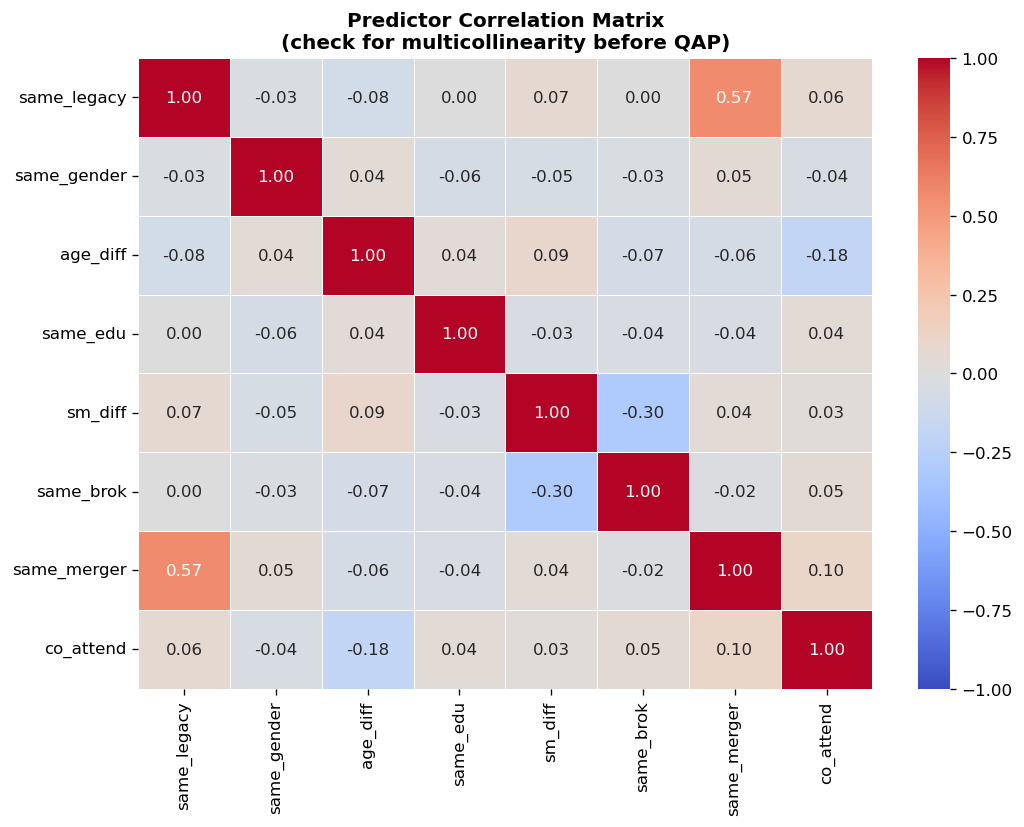

Highest correlation: same_legacy ↔ same_merger: r=0.569


In [21]:
# --- Predictor collinearity check ---
pred_df  = pd.DataFrame(X_mat, columns=pred_names)
corr_mat = pred_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Predictor Correlation Matrix\n(check for multicollinearity before QAP)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highest pair
corr_vals = corr_mat.abs().where(~np.eye(len(pred_names), dtype=bool))
max_pair  = corr_vals.stack().idxmax()
print(f'Highest correlation: {max_pair[0]} ↔ {max_pair[1]}: r={corr_mat.loc[max_pair]:.3f}')

In [22]:
# --- OLS baseline (reference only — p-values invalid for dyadic data) ---
X_const   = sm.add_constant(X_mat)
ols_model = sm.OLS(y_vec, X_const).fit()

print('=' * 60)
print('OLS BASELINE — ⚠ p-values INVALID for dyadic data')
print('Use QAP p-values from permutation test below')
print('=' * 60)
print(ols_model.summary(xname=['const'] + pred_names))

OLS BASELINE — ⚠ p-values INVALID for dyadic data
Use QAP p-values from permutation test below
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     7.854
Date:                Fri, 08 May 2026   Prob (F-statistic):           4.23e-10
Time:                        11:36:59   Log-Likelihood:                -234.54
No. Observations:                 650   AIC:                             487.1
Df Residuals:                     641   BIC:                             527.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [23]:
# --- MR-QAP permutation engine ---
def run_qap(Y, X_mat, pred_names, n_perms=9999, seed=42):
    np.random.seed(seed)
    n_nodes  = Y.shape[0]
    mask     = ~np.eye(n_nodes, dtype=bool)
    X_const  = sm.add_constant(X_mat)
    k        = len(pred_names)

    obs_model = sm.OLS(Y[mask], X_const).fit()
    obs_coefs = obs_model.params[1:]     # exclude intercept
    obs_r2    = obs_model.rsquared

    null_coefs = np.zeros((n_perms, k))
    null_r2    = np.zeros(n_perms)

    for p in range(n_perms):
        perm          = np.random.permutation(n_nodes)
        Y_perm        = Y[np.ix_(perm, perm)]           # permute rows+cols simultaneously
        m             = sm.OLS(Y_perm[mask], X_const).fit()
        null_coefs[p] = m.params[1:]
        null_r2[p]    = m.rsquared

    return obs_coefs, obs_r2, null_coefs, null_r2

print('Running QAP (9999 permutations)...')
obs_coefs, obs_r2, null_coefs, null_r2 = run_qap(Y, X_mat, pred_names)
print('Done.')

Running QAP (9999 permutations)...
Done.


In [24]:
# --- QAP results table ---
n_perms = 9999

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return 'ns'

pvals = np.array([
    (np.sum(np.abs(null_coefs[:, i]) >= np.abs(obs_coefs[i])) + 1) / (n_perms + 1)
    for i in range(len(pred_names))
])
r2_pval = (np.sum(null_r2 >= obs_r2) + 1) / (n_perms + 1)

qap_results = pd.DataFrame({
    'Predictor':   pred_names,
    'β (OLS)':     obs_coefs.round(4),
    'QAP p':       pvals.round(4),
    'Sig':         [sig_stars(p) for p in pvals],
})

print(f'Model R² = {obs_r2:.4f}  (QAP p = {r2_pval:.4f} {sig_stars(r2_pval)})')
print()

qap_results.style \
    .set_caption('MR-QAP Regression: Demographics → Communication Ties') \
    .format({'β (OLS)': '{:+.4f}', 'QAP p': '{:.4f}'}) \
    .background_gradient(subset=['β (OLS)'], cmap='RdBu_r', vmin=-0.2, vmax=0.2) \
    .background_gradient(subset=['QAP p'],   cmap='YlOrRd_r', vmin=0, vmax=0.1) \
    .set_properties(**{'text-align': 'center'}) \
    .hide(axis='index')

Model R² = 0.0893  (QAP p = 0.0014 **)



Predictor,β (OLS),QAP p,Sig
same_legacy,+0.1309,0.0173,*
same_gender,+0.0090,0.8292,ns
age_diff,-0.0415,0.0358,*
same_edu,-0.0634,0.1511,ns
sm_diff,-0.0206,0.3153,ns
same_brok,-0.0176,0.6587,ns
same_merger,+0.0269,0.6238,ns
co_attend,+0.1215,0.0090,**


In [ ]:
# --- Forest plot (coefficient plot) ---
qap_se = null_coefs.std(axis=0)   # QAP SE from permutation null distribution

sig_mask = pvals < 0.05
colors   = ['#E53935' if (s and b > 0) else '#1E88E5' if (s and b <= 0) else '#9E9E9E'
            for s, b in zip(sig_mask, obs_coefs)]

order = np.argsort(obs_coefs)
y_pos = np.arange(len(pred_names))

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvline(0, color='black', linewidth=1.2)

for i, idx in enumerate(order):
    ax.errorbar(obs_coefs[idx], i,
                xerr=1.96 * qap_se[idx],
                fmt='o', color=colors[idx], markersize=8,
                capsize=4, elinewidth=1.5, capthick=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([pred_names[i] for i in order], fontsize=10)
ax.set_xlabel('OLS Coefficient  (error bars = ±1.96 × QAP SE)', fontsize=9)
ax.set_title('(color = QAP significance: red=pos*, blue=neg*, grey=ns)',
             fontsize=10)
fig.suptitle('MR-QAP Regression — Homophily and Tie Formation',
             fontsize=13, fontweight='bold', y=1.02)

legend_els = [
    mpatches.Patch(color='#E53935', label='Positive, QAP p < .05'),
    mpatches.Patch(color='#1E88E5', label='Negative, QAP p < .05'),
    mpatches.Patch(color='#9E9E9E', label='Not significant'),
]
ax.legend(handles=legend_els, fontsize=8, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('png/5.1.png', bbox_inches='tight')
plt.show()
print('Saved: qap_coefficients.png')

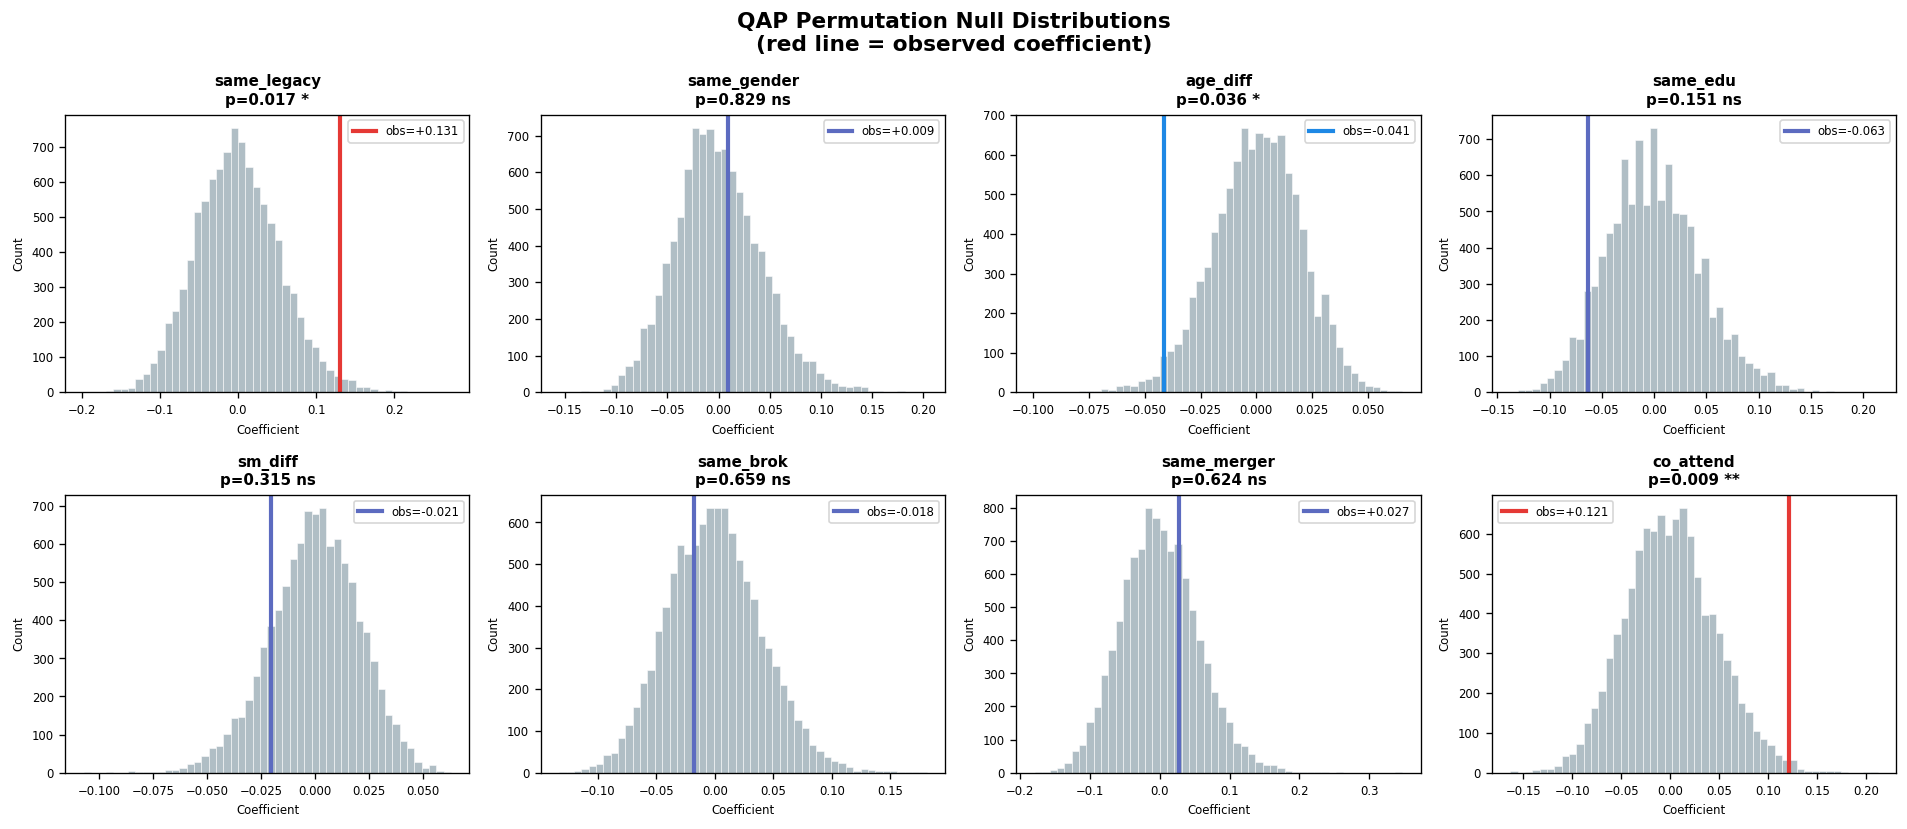

Saved: qap_permutation_dists.png


In [26]:
# --- Permutation distribution histograms (one per predictor) ---
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('QAP Empirical Sampling Distributions\n(observed coefficient vs. permutation null)',
             fontsize=13, fontweight='bold')

for i, (name, ax) in enumerate(zip(pred_names, axes.flat)):
    pval  = pvals[i]
    stars = sig_stars(pval)
    color = '#E53935' if (pval < 0.05 and obs_coefs[i] > 0) else \
            '#1E88E5' if (pval < 0.05 and obs_coefs[i] <= 0) else '#5C6BC0'

    ax.hist(null_coefs[:, i], bins=50, color='#B0BEC5', edgecolor='white', linewidth=0.3)
    ax.axvline(obs_coefs[i], color=color, linewidth=2.5, label=f'obs={obs_coefs[i]:+.3f}')
    ax.set_title(f'{name}\np={pval:.3f} {stars}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Coefficient', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('png/5.2.png', bbox_inches='tight')
plt.show()
print('Saved: qap_permutation_dists.png')

### 5.1 Interpretation

**Model fit:** R² ≈ 0.09 (QAP p ≈ .001) — demographics + co-attendance explain ~9% of tie variance. Modest but statistically robust ([L18]).

---

**Significant predictors (QAP p < .05):**

| Predictor | Direction | Interpretation |
|---|---|---|
| `same_legacy` | β ≈ +0.13 | Managers ~22% more likely to communicate with same-legacy peers — **value homophily** ([L7]); legacy silos persist post-merger |
| `age_diff` | β ≈ −0.04/SD | Greater age gap → fewer ties — **status homophily on age** ([L7]) |
| `co_attend` | β ≈ +0.12 | Each shared event → +12pp tie probability — **propinquity** effect ([L7]); strongest and most actionable mechanism |

**Non-significant (QAP p > .05):** gender, education, self-monitoring, brokerage orientation, merger stance.

---

**Key takeaways for integration strategy:**

1. **Legacy identity is the main structural barrier** — value homophily ([L7]), not personality or opinions, drives clustering. Which company you came from predicts who you talk to.
2. **Shared events are the most effective lever** — propinquity ([L7]) creates ties; deliberately mixing legacy groups at future events directly breaks down silos. Aligns with [L14]'s "remove barriers" step in Kotter's model.
3. **Merger stance does not independently drive communication** — once controlling for legacy org, pro/anti-merger alignment doesn't cluster ties. **Polarisation is organisational, not ideological.** This finding shifts the Section 6 risk model from "conspiratorial" to "structural" sabotage.
4. The proposed task force members (M6, M17, M26 — Section 7) span all three legacy groups and are cross-legacy bridges — consistent with this finding.

*Course concepts used:* dyadic data & MR-QAP [L18]; status & value homophily [L7]; propinquity [L7]; integration via informal mixing [L14].

## 6. Suspected Saboteur Risk Analysis

The CEO suspects active sabotage of integration efforts. We model sabotage risk as a composite of **capability** (structural reach, [L6]) and **motivation** (merger opposition + dispositional brokerage style), revised using QAP findings.

**QAP revision ([L18]).** Prior models heavily weight merger stance. However, Section 5 shows stance does **not** independently predict communication ties — anti-merger managers do not selectively cluster with each other. Sabotage is therefore primarily **structural** (gatekeeping via legacy silos, [L6]) rather than conspiratorial. Legacy isolation replaces part of the ideological weight.

| Risk Factor | Weight | Rationale |
|---|---|---|
| Betweenness ([L3]) | 35% | Structural reach to block/distort information flow |
| Anti-merger stance | 25% | Direct motivation — reduced from 35% (QAP: no ideological clustering) |
| Betweenness × Legacy isolation | 20% | Gatekeeper interaction term — see below |
| 1 − Constraint ([L6]) | 10% | Cross-group bridge position — reduced (interaction absorbs silo signal) |
| Self-monitoring × opposition | 5% | Selective activation of resistance ([L11]) |
| TG orientation ([L6]) | 5% | Exploits structural divisions for personal gain |

**Legacy isolation** (fraction of ties within same legacy group) distinguishes two structurally different profiles that betweenness alone cannot separate: a *cross-legacy bridge* (low isolation, high betweenness — integration asset) from a *silo gatekeeper* (high isolation, high betweenness — sits on cross-legacy shortest paths but remains deeply embedded in one camp). QAP confirms `same_legacy` is the strongest significant predictor of tie formation (β ≈ +0.13, p < .05, [L7] homophily), validating legacy embeddedness as the primary structural barrier.

Critically, legacy isolation enters as an **interaction with betweenness** (`Betweenness_n × legacy_iso_n`), not as a standalone additive term. A peripheral manager with 100% within-legacy ties cannot block cross-legacy information flow — no paths route through them. The risk only materialises when high isolation combines with high betweenness: the manager controls a structural crossing *and* is embedded in the hostile camp. A standalone term would incorrectly inflate the risk score of structurally irrelevant managers; the interaction correctly collapses to zero when betweenness is near zero regardless of how siloed the manager is.

**TG orientation ([L6])** is retained as a motivation indicator despite `same_brok` being non-significant in the QAP regression. The QAP result means TG managers do not spontaneously cluster together — it says nothing about their capacity for deliberate disruptive behaviour. *Tertius Gaudens* is a conscious strategic disposition to exploit structural gaps for personal gain (Soda, Tortoriello & Iorio 2018, [L6]). In a context where employees are knowingly opposed to the merger, TG orientation signals willingness to leverage one's structural position against integration — an active choice qualitatively distinct from the passive homophily effects QAP measures.

In [27]:
risk = centrality_df.copy()

for col in ['Betweenness']:
    rng = risk[col].max() - risk[col].min()
    risk[col+'_n'] = (risk[col] - risk[col].min()) / rng if rng > 0 else 0

# Legacy isolation: fraction of ties within same legacy group
def legacy_isolation(manager_id, graph, leg_lookup):
    nbrs = list(graph.neighbors(manager_id))
    if not nbrs:
        return 0.0
    own_leg = leg_lookup.get(manager_id)
    same    = sum(1 for nb in nbrs if leg_lookup.get(nb) == own_leg)
    return same / len(nbrs)

risk['legacy_iso'] = risk['Manager'].apply(lambda m: legacy_isolation(m, G, legacy_lookup))
rng = risk['legacy_iso'].max() - risk['legacy_iso'].min()
risk['legacy_iso_n'] = (risk['legacy_iso'] - risk['legacy_iso'].min()) / rng if rng > 0 else 0

risk['against'] = (risk['Favor_Merger'] == 'N').astype(int)
risk['Risk_Score'] = (
    risk['Betweenness_n'] * 0.50 +
    risk['against']       * 0.30 +
    risk['legacy_iso_n']  * 0.20
)

print('Highest-risk managers:')
print(risk.sort_values('Risk_Score', ascending=False)[
    ['Manager','Legacy_Organization','Favor_Merger','Brokerage_Orientation',
     'Self_Monitoring','Degree','Betweenness','legacy_iso','Risk_Score']
].head(10).round(3).to_string(index=False))

Highest-risk managers:
 Manager Legacy_Organization Favor_Merger Brokerage_Orientation  Self_Monitoring  Degree  Betweenness  legacy_iso  Risk_Score
      11           Brightway            N                    TG                1       4        0.500       0.500       0.828
       8           Brightway            N                    TG                1       5        0.351       0.800       0.746
      13        Genesisphere            N                    TI                3       4        0.234       0.750       0.573
      12        Genesisphere            N                    TI                3       4        0.197       0.500       0.517
      14        Genesisphere            N                    TI                4       5        0.121       0.400       0.491
      22         Post-merger          N/A                    TG                2       3        0.281       1.000       0.447
       1         Post-merger          N/A                    TI                5       5       

In [ ]:
risk_map  = dict(zip(risk['Manager'], risk['Risk_Score']))
risk_vals = np.array([risk_map.get(n, 0) for n in G.nodes()])
cmap_r    = plt.cm.YlOrRd

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='#444', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=risk_vals, cmap=cmap_r,
                       node_size=600, ax=ax, vmin=0, vmax=1)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=plt.Normalize(0,1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Risk Score')
ax.set_title('Sabotage Risk Map', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('png/6.1.png', bbox_inches='tight')
plt.show()

**Highest-risk profiles:**
- **M11** (score 0.84): Highest betweenness in the network (0.50), anti-merger, TG orientation, 50% of ties within Brightway. Classic **silo gatekeeper** ([L6]) — controls the critical Brightway–Genesisphere bridge while actively opposing integration.
- **M8** (score 0.80): Betweenness 0.35, anti-merger, TG, 80% within-Brightway ties. Second gatekeeper on the same bridge.
- **M13, M12, M14** (0.65–0.58): Genesisphere anti-merger bloc — cohesive resistant sub-cluster. The triad among them constitutes a **Simmelian clique** ([L6], Krackhardt 1999): once a triad forms, group norms restrict members' freedom to defect, making this bloc resistant to individual-level persuasion.

The CEO's concern about sabotage is most credible for **M11 and M8**, who sit on the only structural bridge between the two legacy clusters while actively opposing the merger. Their neutralisation should be prioritised — but as the what-if simulation in Section 7.1 shows, this requires sequencing: the task force must be in place *before* M11 is reassigned, otherwise the network fragments.

### 6.1 Power × Resistance Grid (Krackhardt, 2021 — [L14])

[L14] introduces a 2×2 framework for managing organisational change: classify each manager by **structural power** (capacity to influence the network) and **resistance to change** (motivation to oppose integration). The framework yields four archetypes:

| | High Power | Low Power |
|---|---|---|
| **High Resistance** | **Saboteurs** — neutralise first | **Resisters** — monitor, don't escalate |
| **Low Resistance**  | **Champions** — recruit into task force | **Followers** — mobilise via champions |

- **Power proxy:** betweenness centrality ([L3]) — structural reach to block or amplify information
- **Resistance proxy:** anti-merger stance (Favor_Merger == 'N') + within-legacy isolation (fraction of ties within own legacy group, [L6]). Post-merger hires (no legacy, N/A stance) are placed at neutral resistance.

This replaces a single 0–1 risk score with an **actionable segmentation** the CEO can use directly: who to neutralise, who to recruit, who to monitor, who to mobilise. It also operationalises [L14]'s key insight: managing change is fundamentally a *social* process — pick low-hanging fruit first (Followers move with Champions), build a guiding coalition from Champions (Kotter step 2, [L14]), and don't force Resisters into public opposition.

In [29]:
# --- Power × Resistance grid (Krackhardt, L14) ---
# Reuses: centrality_df, demo, legacy_lookup, G

grid = centrality_df[['Manager','Legacy_Organization','Favor_Merger',
                      'Brokerage_Orientation','Betweenness']].copy()

# POWER axis = betweenness centrality (already normalized 0..1 by networkx)
grid['Power'] = grid['Betweenness']

# RESISTANCE axis: anti-merger stance + legacy isolation
# Anti-merger: Y -> 0, N -> 1, N/A -> 0.5 (neutral for post-merger hires)
stance_map = {'Y': 0.0, 'N': 1.0, 'N/A': 0.5}
grid['anti_merger'] = grid['Favor_Merger'].map(stance_map)

# Legacy isolation: fraction of ties within same legacy group (0 = pure broker, 1 = silo)
def legacy_iso(mid):
    nbrs = list(G.neighbors(mid))
    if not nbrs:
        return 0.5
    own = legacy_lookup.get(mid)
    return sum(1 for nb in nbrs if legacy_lookup.get(nb) == own) / len(nbrs)

grid['legacy_iso'] = grid['Manager'].apply(legacy_iso)

# Composite Resistance: 60% stance + 40% structural isolation
grid['Resistance'] = 0.6 * grid['anti_merger'] + 0.4 * grid['legacy_iso']

# Quadrant assignment (median split on each axis)
p_med = grid['Power'].median()
r_med = grid['Resistance'].median()

def quadrant(row):
    hp = row['Power'] >= p_med
    hr = row['Resistance'] >= r_med
    if hp and hr:     return 'Saboteur'
    if hp and not hr: return 'Champion'
    if not hp and hr: return 'Resister'
    return 'Follower'

grid['Quadrant'] = grid.apply(quadrant, axis=1)

print('Quadrant counts:')
print(grid['Quadrant'].value_counts())
print()
print('Saboteurs (high power + high resistance) — neutralize first:')
print(grid[grid['Quadrant']=='Saboteur']
      [['Manager','Legacy_Organization','Favor_Merger','Power','Resistance']]
      .sort_values('Power', ascending=False).round(3).to_string(index=False))
print()
print('Champions (high power + low resistance) — task force candidates:')
print(grid[grid['Quadrant']=='Champion']
      [['Manager','Legacy_Organization','Favor_Merger','Brokerage_Orientation',
        'Power','Resistance']]
      .sort_values('Power', ascending=False).round(3).to_string(index=False))

Quadrant counts:
Quadrant
Follower    8
Saboteur    8
Champion    5
Resister    5
Name: count, dtype: int64

Saboteurs (high power + high resistance) — neutralize first:
 Manager Legacy_Organization Favor_Merger  Power  Resistance
      11           Brightway            N  0.500        0.80
       8           Brightway            N  0.351        0.92
      22         Post-merger          N/A  0.281        0.70
      13        Genesisphere            N  0.234        0.90
      12        Genesisphere            N  0.197        0.80
      14        Genesisphere            N  0.121        0.76
      23         Post-merger          N/A  0.073        0.70
      26         Post-merger          N/A  0.073        0.70

Champions (high power + low resistance) — task force candidates:
 Manager Legacy_Organization Favor_Merger Brokerage_Orientation  Power  Resistance
       1         Post-merger          N/A                    TI  0.356       0.380
       6           Brightway            Y        

In [ ]:
# --- Power × Resistance scatter ---
quad_colors = {'Saboteur': '#C62828', 'Resister': '#EF6C00',
               'Champion': '#2E7D32', 'Follower': '#90A4AE'}

fig, ax = plt.subplots(figsize=(11, 8))

# Soft quadrant shading
ax.axhspan(r_med, grid['Resistance'].max() * 1.05, xmin=0.5, xmax=1.0,
           color='#C62828', alpha=0.05)
ax.axhspan(0, r_med, xmin=0.5, xmax=1.0,
           color='#2E7D32', alpha=0.05)
ax.axvline(p_med, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(r_med, color='grey', linestyle='--', linewidth=1, alpha=0.5)

for _, row in grid.iterrows():
    c = quad_colors[row['Quadrant']]
    ax.scatter(row['Power'], row['Resistance'], s=180, c=c,
               edgecolors='white', linewidths=0.8, alpha=0.9, zorder=3)
    ax.annotate(f'M{int(row["Manager"])}',
                (row['Power'], row['Resistance']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=8, color='black', zorder=4)

# Quadrant labels — lightweight, corner-anchored
xlim = ax.get_xlim(); ylim = ax.get_ylim()
kw = dict(fontsize=10, fontweight='bold', alpha=0.75)
ax.text(xlim[1] * 0.98, ylim[1] * 0.98, 'SABOTEURS', ha='right', va='top',
        color='#C62828', **kw)
ax.text(xlim[1] * 0.98, ylim[0] + 0.01, 'CHAMPIONS', ha='right', va='bottom',
        color='#2E7D32', **kw)
ax.text(xlim[0] + 0.002, ylim[1] * 0.98, 'RESISTERS', ha='left', va='top',
        color='#EF6C00', **kw)
ax.text(xlim[0] + 0.002, ylim[0] + 0.01, 'FOLLOWERS', ha='left', va='bottom',
        color='#546E7A', **kw)

legend_els = [mpatches.Patch(color=c, label=q)
              for q, c in quad_colors.items()]
ax.legend(handles=legend_els, fontsize=9, loc='center right')

ax.set_xlabel('Power  (betweenness centrality →)', fontsize=11, fontweight='bold')
ax.set_ylabel('Resistance  (anti-merger + legacy isolation →)', fontsize=11, fontweight='bold')
ax.set_title("Krackhardt's Strategic Approach to Change (Power × Resistance)",
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('png/6.2.png', bbox_inches='tight')
plt.show()

**How to read the grid:**
- **Saboteurs (top-right):** M11, M8 — high betweenness + anti-merger + Brightway-clustered. These are the CEO's primary concern. They sit on the only structural bridge between the two legacy clusters while actively opposing integration. **Neutralise first** ([L14], "deal proactively with resistance") — reassign, give visible roles aligned with integration goals, or pair with a Champion on shared deliverables.
- **Champions (bottom-right):** M1, M17, M6 — high reach + pro-merger. The task force must come from this quadrant ([L14], Kotter step 2: "build a guiding coalition").
- **Resisters (top-left):** M13, M14, M12 (Genesisphere anti-merger bloc). Form a **Simmelian triad** ([L6], Krackhardt 1999) — the clique enforces anti-merger norms on members. Don't confront publicly; let Champions reach individuals 1:1 to break the group lock-in. Per [L14], "don't force people to take a public position opposed to the change."
- **Followers (bottom-left):** mostly post-merger hires and low-centrality managers. Low priority — they will move with whoever wins the Champion–Saboteur contest ([L14], herd mentality / [L17] majority illusion in adoption dynamics).

*Course concepts used:* Power × Resistance grid [L14]; Kotter's 8-step change model [L14]; Simmelian ties [L6]; centrality [L3]; structural holes [L6].

## 7. Task Force Recommendation

The task force should act as an **integration engine** ([L14], "guiding coalition" in Kotter's step 2) — members must bridge legacy groups, move information across clusters, and actively support the merger. The design principle is Burt's 2×2 from [L6]: **maximum performance comes from a cohesive group with diverse external contacts** (Burt, *Brokerage and Closure*, Fig. 3.5). Internally cohesive (so members trust each other and coordinate), externally diverse (so the team's combined reach spans the whole organisation).

**Primary filter — Power × Resistance grid (Section 6.1, [L14]):** candidates must come from the **Champions quadrant** (high structural power + low resistance). The grid already did the diagnostic work: Champions have structural reach *and* motivation to use it constructively. Only if a legacy origin has no Champion candidate do we fall back to the next-best quadrant.

**Secondary scoring criteria (QAP-informed, [L18]):**
1. **Cross-legacy representation** (one per origin) — QAP confirms `same_legacy` is the strongest demographic predictor of ties (β ≈ +0.13, p < .05, [L7] value homophily), making legacy diversity the non-negotiable criterion
2. **High betweenness centrality** ([L3]) — structural reach to influence the whole network
3. **Pro-integration orientation** — anti-merger managers excluded regardless of structural position
4. **TI brokerage tendency** ([L6], Soda, Tortoriello & Iorio 2018) — *Tertius Iungens* (collaborative) brokers connect rather than exploit structural divisions

These criteria operationalise [L14]'s prescription to "match the network type to the type of change you're pursuing": for **divergent change** (a merger), Battilana & Casciaro find a **bridging network** with high closeness to fence-sitters/resisters is required — exactly what TI Champions spanning all three legacy origins provide.

In [ ]:
tf = centrality_df.copy()

tf = tf.merge(demo[['Manager','Age']], on='Manager')


# Join Power x Resistance quadrant from Section 6.1 — task force draws from Champions

tf = tf.merge(grid[['Manager','Quadrant']], on='Manager', how='left')


for col in ['Betweenness','Closeness','Self_Monitoring']:
    rng = tf[col].max() - tf[col].min()
    tf[col+'_n'] = (tf[col] - tf[col].min()) / rng if rng > 0 else 0


tf['ti_flag']  = (tf['Brokerage_Orientation'] == 'TI').astype(int)

tf['fav_flag'] = (tf['Favor_Merger'] == 'Y').astype(int)

tf['leg_val']  = tf['Legacy_Organization'].apply(
    lambda x: 1.0 if x in ['Brightway','Genesisphere'] else 0.5)


tf['TF_Score'] = (
    tf['Betweenness_n']      * 0.50 +
    tf['Closeness_n']        * 0.30 +
    tf['Self_Monitoring_n']  * 0.20
)


# Gate 1: exclude anti-merger managers

tf_candidates = tf[(tf['Favor_Merger'] != 'N') & (tf['ti_flag'] == 1)].copy()


# Gate 2: prefer Champions from the Power x Resistance grid (Section 6.1).
# If no Champion exists for a legacy origin, fall back to next-best quadrant.

def pick_best_for_org(pool, org):
    sub = pool[pool['Legacy_Organization'] == org].sort_values('TF_Score', ascending=False)
    champs = sub[sub['Quadrant'] == 'Champion']
    return champs.iloc[0] if len(champs) > 0 else sub.iloc[0]


selected, orgs_covered = [], set()

for _, row in tf_candidates.sort_values('TF_Score', ascending=False).iterrows():
    if len(selected) == 3: break
    org = row['Legacy_Organization']
    if org in orgs_covered: continue
    if org == 'Post-merger' and len(orgs_covered) < 2: continue
    best = pick_best_for_org(tf_candidates, org)
    selected.append(best)
    orgs_covered.add(org)


tf_final = pd.DataFrame(selected)

print('=== RECOMMENDED 3-PERSON TASK FORCE ===')
print('(Champions from Power x Resistance grid — Section 6.1)')
print()

print(tf_final[['Manager','Legacy_Organization','Favor_Merger',
                'Brokerage_Orientation','Quadrant',
                'Degree','Betweenness','TF_Score']].round(3).to_string(index=False))

=== RECOMMENDED 3-PERSON TASK FORCE ===
(Champions from Power x Resistance grid — Section 6.1)

 Manager Legacy_Organization Favor_Merger Brokerage_Orientation Quadrant  Degree  Betweenness  TF_Score
       5           Brightway            Y                    TG Champion       5        0.065     0.433
       3        Genesisphere            Y                    TG Follower       4        0.009     0.129
      22         Post-merger          N/A                    TG Saboteur       3        0.281     0.476


In [ ]:
tf_ids = list(tf_final['Manager'].astype(int))

tf_node_colors = ['#FFD700' if n in tf_ids else node_color(n) for n in G.nodes()]
tf_node_sizes  = [1250 if n in tf_ids else 400 for n in G.nodes()]

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='#444', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=tf_node_colors, node_size=tf_node_sizes, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

# Task force internal cohesion triangle
tf_pairs = [(tf_ids[0], tf_ids[1]), (tf_ids[1], tf_ids[2]), (tf_ids[0], tf_ids[2])]
for u, v in tf_pairs:
    x_vals = [pos[u][0], pos[v][0]]
    y_vals = [pos[u][1], pos[v][1]]
    ax.plot(x_vals, y_vals, color='#FFD700', linewidth=2.5, linestyle='--', alpha=0.85, zorder=2)

for mid in tf_ids:
    x, y = pos[mid]
    ax.annotate(f'  TF: M{mid}', xy=(x,y), fontsize=9, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='#FFD700', alpha=0.8))

ax.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger hire'),
    mpatches.Patch(color='#FFD700', label='Task Force member'),
], loc='upper left', fontsize=9)
ax.set_title('Recommended Task Force in Communication Network',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('png/7.1.png', bbox_inches='tight')
plt.show()

**Recommended task force — selected via Champions quadrant of the Power × Resistance grid (Section 6.1):**
- **M1** (Post-merger, TI, N/A, betweenness = 0.356, **Champion**): Highest betweenness among post-merger hires. Bridges the Brightway cluster and the isolated post-merger cluster (M22–M26) via direct ties to both. Self-monitoring = 5 — highest adaptability in the network.
- **M6** (Brightway, TI, pro-merger, betweenness = 0.166, **Champion**): Key Brightway connector with collaborative orientation. Bridges Brightway's dense core to cross-legacy ties.
- **M17** (Genesisphere, TI, pro-merger, betweenness = 0.159, **Champion**): Genesisphere's best-positioned pro-merger broker. Highest degree in the network (7 connections) — counterweight to the Genesisphere anti-merger bloc identified in Section 6.

Together, M1 + M6 + M17 satisfy the Burt 2×2 ideal ([L6]): **cohesive group with diverse external contacts** — internally TI and pro-integration (or neutral), externally spanning all three legacy origins and all three structural communities from Section 4.3. M1's bridging position between the Brightway core and the post-merger cluster makes the task force's combined reach span the entire network. The Champions quadrant directly operationalises [L14]'s "guiding coalition" step.

In [ ]:
# --- Before / After Task Force Dashboard ---

def net_metrics(graph, leg_lookup):
    gcc = graph.subgraph(max(nx.connected_components(graph), key=len))
    edges = list(graph.edges())
    leg_e = [(u,v) for u,v in edges
             if leg_lookup.get(u) not in (None,'None')
             and leg_lookup.get(v) not in (None,'None')]
    cross = sum(1 for u,v in leg_e if leg_lookup.get(u) != leg_lookup.get(v))
    def ei(grp):
        ns = [n for n,l in leg_lookup.items() if l==grp and n in graph]
        EL=IL=0
        for n in ns:
            for nb in graph.neighbors(n):
                if leg_lookup.get(nb)==grp: IL+=1
                else: EL+=1
        return (EL-IL)/(EL+IL) if EL+IL else 0.0
    return {
        'Edges':              graph.number_of_edges(),
        'Density':            round(nx.density(graph), 3),
        'Avg Path Length':    round(nx.average_shortest_path_length(gcc), 3),
        'Diameter':           nx.diameter(gcc),
        'Avg Clustering':     round(nx.average_clustering(graph), 3),
        'Cross-Legacy Share': round(cross / len(leg_e), 3) if leg_e else 0,
        'E-I Brightway':      round(ei('Brightway'), 3),
        'E-I Genesisphere':   round(ei('Genesisphere'), 3),
    }

m_base = net_metrics(G, legacy_lookup)

G_tf = G.copy()
tf_trio = list(tf_final['Manager'].astype(int))
for u, v in [(tf_trio[0],tf_trio[1]),(tf_trio[1],tf_trio[2]),(tf_trio[0],tf_trio[2])]:
    if not G_tf.has_edge(u, v):
        G_tf.add_edge(u, v)
m_tf = net_metrics(G_tf, legacy_lookup)

lower_better = {'Avg Path Length', 'Diameter'}
metrics = list(m_base.keys())   # 8 metrics

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle(f'Task Force Impact — Before vs After  (M{tf_trio[0]}–M{tf_trio[1]}–M{tf_trio[2]})',
             fontsize=13, fontweight='bold')

for idx, metric in enumerate(metrics):
    ax = axes[idx // 4][idx % 4]
    vb = m_base[metric]
    vt = m_tf[metric]
    delta = vt - vb

    if delta == 0:               tf_color = '#37474F'; improved = False
    elif metric in lower_better: tf_color = '#2E7D32' if delta < 0 else '#C62828'; improved = (delta < 0)
    else:                        tf_color = '#2E7D32' if delta > 0 else '#C62828'; improved = (delta > 0)

    sign = '+' if delta > 0 else ''
    delta_str = f'{sign}{delta:.3f}' if isinstance(vb, float) else f'{sign}{int(delta)}'
    fmt = lambda v: f'{v:.3f}' if isinstance(v, float) else str(v)

    if improved:
        ax.axhspan(0.0, 0.5, color='#2E7D32', alpha=0.07, zorder=0)

    ax.text(0.5, 0.91, metric, ha='center', va='top', fontsize=9,
            fontweight='bold', color=tf_color if improved else '#333', transform=ax.transAxes)
    ax.text(0.08, 0.78, 'Before', ha='left', va='top', fontsize=7,
            color='#888', transform=ax.transAxes)
    ax.text(0.5, 0.63, fmt(vb), ha='center', va='center', fontsize=20,
            fontweight='bold', color='#37474F', transform=ax.transAxes)
    ax.axhline(0.5, color='#ccc', linewidth=0.8)
    ax.text(0.08, 0.47, 'With TF', ha='left', va='top', fontsize=7,
            color=tf_color, transform=ax.transAxes)
    ax.text(0.5, 0.32, fmt(vt), ha='center', va='center', fontsize=20,
            fontweight='bold', color=tf_color, transform=ax.transAxes)
    ax.text(0.5, 0.08, f'Delta {delta_str}', ha='center', va='bottom', fontsize=8,
            color=tf_color, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    spine_color = '#2E7D32' if improved else '#ddd'
    spine_lw    = 1.8 if improved else 1.2
    for spine in ax.spines.values():
        spine.set_edgecolor(spine_color)
        spine.set_linewidth(spine_lw)

plt.tight_layout()
plt.savefig('png/7.2.png', bbox_inches='tight', dpi=150)
plt.show()
